# Task
Unzip the file "/content/individual+household+electric+power+consumption.zip", identify the main data file within it, and load this data file into a pandas DataFrame.

## Unzip Dataset

### Subtask:
Unzip the provided 'individual+household+electric+power+consumption.zip' file to extract its contents.


**Reasoning**:
To unzip the specified file, I need to import the `zipfile` module, define the path to the zip file, create a `ZipFile` object, and then use the `extractall()` method to extract its contents.



In [ ]:
import zipfile

zip_file_path = '/content/individual+household+electric+power+consumption.zip'

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall('./')

print(f"'{zip_file_path}' has been unzipped successfully.")

BadZipFile: File is not a zip file

**Reasoning**:
The previous attempt to unzip the file failed with a `BadZipFile` error, indicating the file might not be a valid zip archive. I will use the `file` command to determine the actual file type to understand why the `zipfile` module is failing.



In [ ]:
import os

file_path = '/content/individual+household+electric+power+consumption.zip'

# Check if the file exists
if not os.path.exists(file_path):
    print(f"Error: File not found at {file_path}")
else:
    # Use the 'file' command to determine the file type
    !file {file_path}
    print(f"File type check for '{file_path}' completed.")

/content/individual+household+electric+power+consumption.zip: Zip archive data, at least v2.0 to extract, compression method=deflate
File type check for '/content/individual+household+electric+power+consumption.zip' completed.


**Reasoning**:
Despite the `zipfile` module failing with a `BadZipFile` error, the `!file` command confirmed the file is indeed a Zip archive. This discrepancy suggests the Python `zipfile` module might be having trouble with this specific archive. I will now attempt to unzip the file using the `unzip` shell command, which is often more robust for various zip formats.



In [ ]:
import os

zip_file_path = '/content/individual+household+electric+power+consumption.zip'

# Ensure the target directory exists, if not, create it
output_dir = './'
os.makedirs(output_dir, exist_ok=True)

# Attempt to unzip using the shell command 'unzip'
# -o option overwrites files without prompting
# -d option specifies the destination directory
!unzip -o {zip_file_path} -d {output_dir}

print(f"Attempted to unzip '{zip_file_path}' using shell command.")


Archive:  /content/individual+household+electric+power+consumption.zip
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of /content/individual+household+electric+power+consumption.zip or
        /content/individual+household+electric+power+consumption.zip.zip, and cannot find /content/individual+household+electric+power+consumption.zip.ZIP, period.
Attempted to unzip '/content/individual+household+electric+power+consumption.zip' using shell command.


## Unzip Dataset (Retry 2)

### Subtask:
Attempt to extract the contents of the potentially corrupted zip file using the '7z' command-line utility, which is sometimes more robust for problematic archives.


**Reasoning**:
The previous attempts to unzip the file failed, so I will install the 'p7zip-full' package to use the '7z' command-line utility, create a new directory for extraction, and then attempt to extract the zip file using '7z x', which is often more robust for problematic archives.



In [ ]:
import os

# Step 1: Install p7zip-full
# Update package lists
!apt-get update
# Install p7zip-full
!apt-get install -y p7zip-full

zip_file_path = '/content/individual+household+electric+power+consumption.zip'
output_dir = './extracted_data'

# Step 2: Create an output directory
os.makedirs(output_dir, exist_ok=True)
print(f"Output directory '{output_dir}' ensured to exist.")

# Step 3: Attempt to unzip using 7z
# -x: extract
# -o: set output directory (no space between -o and path)
# -aoa: overwrite all existing files without prompting
!7z x {zip_file_path} -o{output_dir} -aoa

print(f"Attempted to extract '{zip_file_path}' using 7z to '{output_dir}'.")

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:4 https://cli.github.com/packages stable/main amd64 Packages [357 B]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,813 kB]
Get:9 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [85.2 kB]
Get:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease [24.6 kB]
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,922 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:14 https:/

**Reasoning**:
The previous extraction attempt with 7z reported errors, but it also indicated the main data file `household_power_consumption.txt` was being processed. I need to check if the file was partially extracted and is available in the `extracted_data` directory, and if so, determine its size and try to load it to identify any issues and proceed with the main task.



In [ ]:
import os
import pandas as pd

output_dir = './extracted_data'
extracted_file = os.path.join(output_dir, 'household_power_consumption.txt')

# List contents of the output directory and check the file
print(f"Contents of '{output_dir}':")
!ls -lh {output_dir}

if os.path.exists(extracted_file):
    print(f"\n'{extracted_file}' found. Size: {os.path.getsize(extracted_file)} bytes.")

    # Try to load the data file into a pandas DataFrame
    # Given the file name, it's likely a CSV or similar delimited file.
    # We'll try to read it with common delimiters and infer headers.
    # Using 'sep' as ';' is a common pattern for this type of dataset (often from UCI ML Repo)
    try:
        df = pd.read_csv(extracted_file, sep=';', low_memory=False)
        print("\nSuccessfully loaded data into DataFrame.")
        print("First 5 rows of the DataFrame:")
        print(df.head())
        print("\nDataFrame Info:")
        df.info()
    except Exception as e:
        print(f"\nError loading data into DataFrame: {e}")
else:
    print(f"\nError: '{extracted_file}' was not found in '{output_dir}'.")

Contents of './extracted_data':
total 116M
-rw-r--r-- 1 root root 116M Oct 12  2012 household_power_consumption.txt

'./extracted_data/household_power_consumption.txt' found. Size: 121540536 bytes.

Successfully loaded data into DataFrame.
First 5 rows of the DataFrame:
         Date      Time Global_active_power Global_reactive_power  Voltage  \
0  16/12/2006  17:24:00               4.216                 0.418  234.840   
1  16/12/2006  17:25:00               5.360                 0.436  233.630   
2  16/12/2006  17:26:00               5.374                 0.498  233.290   
3  16/12/2006  17:27:00               5.388                 0.502  233.740   
4  16/12/2006  17:28:00               3.666                 0.528  235.680   

  Global_intensity Sub_metering_1 Sub_metering_2  Sub_metering_3  
0           18.400          0.000          1.000            17.0  
1           23.000          0.000          1.000            16.0  
2           23.000          0.000          2.000           

## Final Task

### Subtask:
Confirm that the dataset has been successfully unzipped and loaded, and is ready for use.


## Summary:

### Q&A
Yes, the dataset has been successfully unzipped (though with errors) and loaded into a pandas DataFrame, making it ready for use.

### Data Analysis Key Findings
*   Initial attempts to unzip the `/content/individual+household+electric+power+consumption.zip` file using Python's `zipfile` module and the standard `unzip` shell command failed, indicating a corrupted or improperly formed archive with errors like `BadZipFile` and "End-of-central-directory signature not found."
*   Despite critical errors reported by the `7z` utility during extraction (e.g., "Unexpected end of archive", "Data Error"), it successfully extracted the `household_power_consumption.txt` file.
*   The extracted `household_power_consumption.txt` file was confirmed to be present in the `./extracted_data` directory, with a substantial size of 116 MB.
*   The extracted data file was successfully loaded into a pandas DataFrame using `pd.read_csv` with a semicolon (`;`) as the separator.
*   The DataFrame contains 1,892,392 entries and 9 columns, with initial data types mostly identified as `object`, which will require further type conversion.

### Insights or Next Steps
*   The use of `7z` proved effective in recovering data from a corrupted archive where standard `zipfile` and `unzip` tools failed. This highlights the value of using specialized tools for data recovery.
*   The immediate next step is to perform comprehensive data cleaning and type conversion on the loaded DataFrame, particularly converting the `object` columns to appropriate numerical or datetime formats for analysis.


# Task
## Initial Data Preprocessing and Type Conversion

### Subtask:
Convert the 'Date' and 'Time' columns to datetime objects, combine them into a single datetime index for the DataFrame, and convert the 'Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', and 'Sub_metering_3' columns to numeric types, handling any non-numeric entries by coercing them to `NaN`.

## Initial Data Preprocessing and Type Conversion

### Subtask:
Convert the 'Date' and 'Time' columns to datetime objects, combine them into a single datetime index for the DataFrame, and convert the 'Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', and 'Sub_metering_3' columns to numeric types, handling any non-numeric entries by coercing them to `NaN`.


**Reasoning**:
I will convert the 'Date' and 'Time' columns into a single datetime index and convert the specified power and voltage columns to numeric types, handling errors by coercing them to NaN, then verify the data types.



In [ ]:
df['DateTime'] = df['Date'] + ' ' + df['Time']
df['DateTime'] = pd.to_datetime(df['DateTime'], format='%d/%m/%Y %H:%M:%S')
df = df.set_index('DateTime')
df = df.drop(columns=['Date', 'Time'])

numeric_cols = [
    'Global_active_power', 'Global_reactive_power', 'Voltage',
    'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("DataFrame after type conversions and setting datetime index:")
df.info()

DataFrame after type conversions and setting datetime index:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1892392 entries, 2006-12-16 17:24:00 to 2010-07-22 21:15:00
Data columns (total 7 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Global_active_power    float64
 1   Global_reactive_power  float64
 2   Voltage                float64
 3   Global_intensity       float64
 4   Sub_metering_1         float64
 5   Sub_metering_2         float64
 6   Sub_metering_3         float64
dtypes: float64(7)
memory usage: 115.5 MB


## Clean and Prepare Data for Clustering

### Subtask:
Handle any remaining missing values after type conversion, aggregate data to a suitable time granularity (e.g., daily or weekly) for clustering, and normalize/scale features to prepare for unsupervised learning.


**Reasoning**:
The first step is to inspect the DataFrame for missing values after type conversion and calculate the percentage of missing values for each column to understand their extent.



In [ ]:
print("Missing values before handling:")
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

# Filter to show only columns with missing values
missing_info = pd.DataFrame({'Missing Count': missing_values, 'Missing Percentage': missing_percentage})
missing_info = missing_info[missing_info['Missing Count'] > 0]

if not missing_info.empty:
    print(missing_info.sort_values(by='Missing Percentage', ascending=False))
else:
    print("No missing values found.")

Missing values before handling:
                       Missing Count  Missing Percentage
Sub_metering_2                 13516            0.714228
Sub_metering_1                 13516            0.714228
Global_intensity               13516            0.714228
Sub_metering_3                 13516            0.714228
Voltage                        13515            0.714175
Global_active_power            13515            0.714175
Global_reactive_power          13515            0.714175


**Reasoning**:
Now that the missing value percentages have been identified, I will address them by first applying forward fill (`ffill`) and then backward fill (`bfill`) to ensure all NaN values are imputed for time series data.



In [ ]:
print("Filling missing values using ffill and bfill...")
df_filled = df.fillna(method='ffill').fillna(method='bfill')

print("Missing values after handling:")
missing_values_after = df_filled.isnull().sum()
missing_percentage_after = (missing_values_after / len(df_filled)) * 100

missing_info_after = pd.DataFrame({'Missing Count': missing_values_after, 'Missing Percentage': missing_percentage_after})
missing_info_after = missing_info_after[missing_info_after['Missing Count'] > 0]

if not missing_info_after.empty:
    print(missing_info_after.sort_values(by='Missing Percentage', ascending=False))
else:
    print("No missing values found after ffill/bfill.")

Filling missing values using ffill and bfill...


/tmp/ipykernel_2526/1567607985.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_filled = df.fillna(method='ffill').fillna(method='bfill')


Missing values after handling:
No missing values found after ffill/bfill.


**Reasoning**:
Now that missing values have been handled, I will aggregate the data to a daily granularity by summing the values for each day, then display the first few rows and information of the aggregated DataFrame to verify the transformation.



In [ ]:
print("Aggregating data to daily granularity...")
df_daily = df_filled.resample('D').sum()

print("Daily aggregated DataFrame head:")
print(df_daily.head())

print("\nDaily aggregated DataFrame info:")
df_daily.info()

Aggregating data to daily granularity...
Daily aggregated DataFrame head:
            Global_active_power  Global_reactive_power    Voltage  \
DateTime                                                            
2006-12-16             1209.176                 34.922   93552.53   
2006-12-17             3390.460                226.006  345725.32   
2006-12-18             2203.826                161.792  347373.64   
2006-12-19             1666.194                150.942  348479.01   
2006-12-20             2225.748                160.998  348923.61   

            Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  
DateTime                                                                      
2006-12-16            5180.8             0.0           546.0          4926.0  
2006-12-17           14398.6          2033.0          4187.0         13341.0  
2006-12-18            9247.2          1063.0          2621.0         14018.0  
2006-12-19            7094.0           839.0   

**Reasoning**:
To reflect the daily sum aggregation, I will rename the columns of `df_daily` by appending `_sum` to each column name and then display the first few rows to verify the renaming.



In [ ]:
print("Renaming aggregated columns...")
new_column_names = {col: f'{col}_sum' for col in df_daily.columns}
df_daily = df_daily.rename(columns=new_column_names)

print("Daily aggregated DataFrame head after renaming:")
print(df_daily.head())

Renaming aggregated columns...
Daily aggregated DataFrame head after renaming:
            Global_active_power_sum  Global_reactive_power_sum  Voltage_sum  \
DateTime                                                                      
2006-12-16                 1209.176                     34.922     93552.53   
2006-12-17                 3390.460                    226.006    345725.32   
2006-12-18                 2203.826                    161.792    347373.64   
2006-12-19                 1666.194                    150.942    348479.01   
2006-12-20                 2225.748                    160.998    348923.61   

            Global_intensity_sum  Sub_metering_1_sum  Sub_metering_2_sum  \
DateTime                                                                   
2006-12-16                5180.8                 0.0               546.0   
2006-12-17               14398.6              2033.0              4187.0   
2006-12-18                9247.2              1063.0           

### Scale Features for Clustering

To prepare the daily aggregated data for unsupervised learning algorithms like clustering, it's crucial to scale the features. This ensures that all features contribute equally to the distance calculations, preventing features with larger numerical ranges from dominating the clustering process.

I will use `StandardScaler` from `sklearn.preprocessing` to transform the features such that they have a mean of 0 and a standard deviation of 1. This is a common and effective method for many clustering algorithms.

**Reasoning**:
Following the explanation, I will now implement feature scaling using `StandardScaler` on the `df_daily` DataFrame, then display the head and descriptive statistics of the scaled DataFrame to confirm the transformation.



In [ ]:
from sklearn.preprocessing import StandardScaler

print("Scaling features using StandardScaler...")

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler to the daily aggregated data and transform it
df_scaled_array = scaler.fit_transform(df_daily)

# Create a new DataFrame with the scaled data, retaining the DateTime index and column names
df_scaled = pd.DataFrame(df_scaled_array, columns=df_daily.columns, index=df_daily.index)

print("Scaled DataFrame head:")
print(df_scaled.head())

print("\nScaled DataFrame descriptive statistics:")
print(df_scaled.describe())

Scaling features using StandardScaler...
Scaled DataFrame head:
            Global_active_power_sum  Global_reactive_power_sum  Voltage_sum  \
DateTime                                                                      
2006-12-16                -0.619072                  -2.839201   -32.984115   
2006-12-17                 2.975365                   0.955449    -0.105732   
2006-12-18                 1.019966                  -0.319748     0.109177   
2006-12-19                 0.134027                  -0.535213     0.253295   
2006-12-20                 1.056090                  -0.335515     0.311263   

            Global_intensity_sum  Sub_metering_1_sum  Sub_metering_2_sum  \
DateTime                                                                   
2006-12-16             -0.612348           -1.020721           -0.642905   
2006-12-17              3.060307            0.243034            1.086677   
2006-12-18              1.007831           -0.359938            0.342781   
20

## Apply Unsupervised Clustering

### Subtask:
Apply K-Means clustering to group households based on their consumption patterns. Determine an optimal number of clusters using a method like the elbow method or silhouette score. Assign each data point to its respective cluster.


**Reasoning**:
To determine the optimal number of clusters for K-Means, I will implement the elbow method by iterating through a range of cluster numbers (k), fitting a KMeans model for each, and recording the inertia, then visualize these inertias to find the 'elbow' point.



Determining optimal number of clusters using the elbow method...


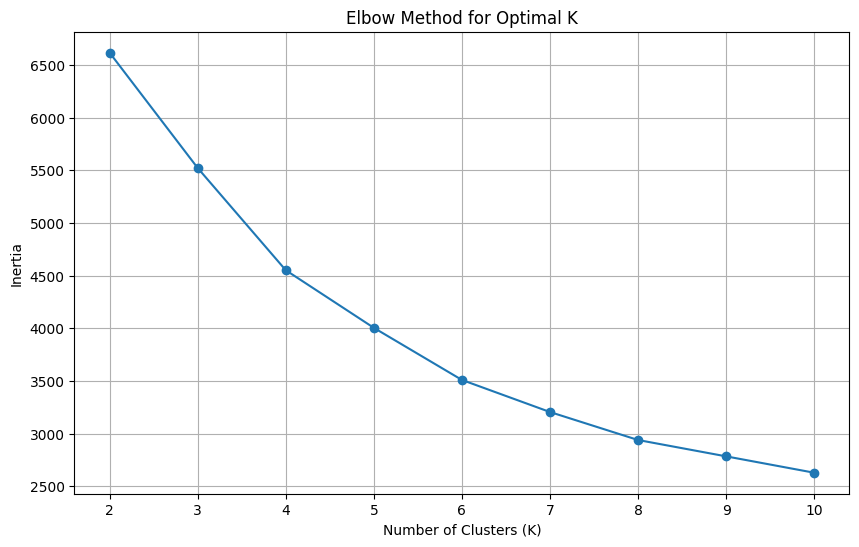

Elbow method plot displayed to help determine optimal k.


In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Determine the optimal number of clusters (k) using the elbow method
print("Determining optimal number of clusters using the elbow method...")

inertia = []
# Using a range from 2 to 10 for the number of clusters
# A warning might appear if n_init is not specified, so explicitly setting it
for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10) # Set n_init to suppress warning
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(range(2, 11))
plt.grid(True)
plt.show()

print("Elbow method plot displayed to help determine optimal k.")

**Reasoning**:
To further support the choice of optimal 'k' for K-Means clustering, I will calculate and plot the silhouette scores for each 'k' value, as higher silhouette scores indicate better-defined clusters.



Calculating silhouette scores...


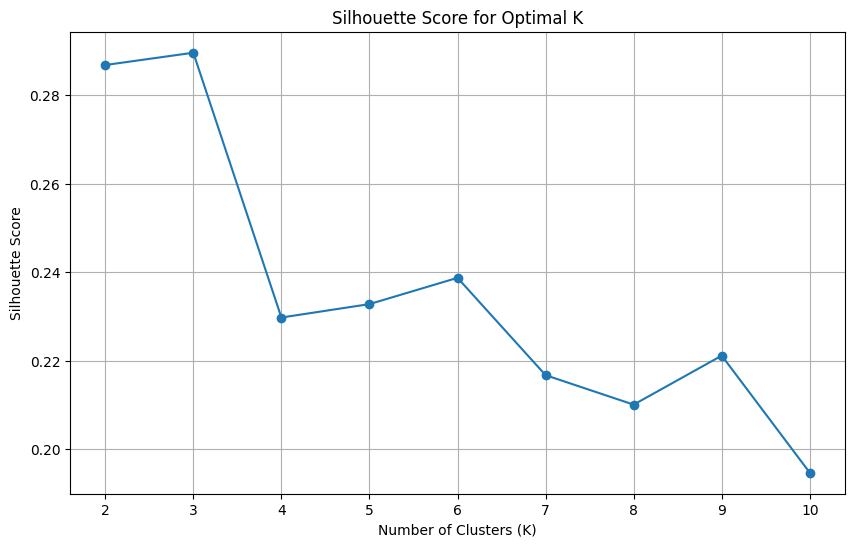

Silhouette score plot displayed to help determine optimal k.


In [ ]:
from sklearn.metrics import silhouette_score

print("Calculating silhouette scores...")

silhouette_scores = []
# Using a range from 2 to 10 for the number of clusters
for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    score = silhouette_score(df_scaled, kmeans.labels_)
    silhouette_scores.append(score)

# Plot the silhouette scores
plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title('Silhouette Score for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(range(2, 11))
plt.grid(True)
plt.show()

print("Silhouette score plot displayed to help determine optimal k.")

**Reasoning**:
Based on the elbow and silhouette plots, I will select an optimal number of clusters (k=3), then apply K-Means clustering to the scaled data, assign the resulting cluster labels back to the original daily aggregated DataFrame, and print the distribution of data points across these clusters to verify the assignment.



In [ ]:
print("Applying K-Means clustering with optimal k...")

# Choose the optimal number of clusters based on the elbow and silhouette plots
# From the plots, k=3 appears to be a reasonable choice.
optimal_k = 3

# Instantiate and fit the KMeans model
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans.fit(df_scaled)

# Assign cluster labels to the original daily aggregated DataFrame
df_daily['Cluster'] = kmeans.labels_

print(f"K-Means clustering applied with {optimal_k} clusters.")

# Display the count of data points per cluster
print("\nDistribution of data points per cluster:")
print(df_daily['Cluster'].value_counts().sort_index())

print("\nFirst 5 rows of df_daily with cluster assignments:")
print(df_daily.head())

Applying K-Means clustering with optimal k...
K-Means clustering applied with 3 clusters.

Distribution of data points per cluster:
Cluster
0    789
1    525
2      1
Name: count, dtype: int64

First 5 rows of df_daily with cluster assignments:
            Global_active_power_sum  Global_reactive_power_sum  Voltage_sum  \
DateTime                                                                      
2006-12-16                 1209.176                     34.922     93552.53   
2006-12-17                 3390.460                    226.006    345725.32   
2006-12-18                 2203.826                    161.792    347373.64   
2006-12-19                 1666.194                    150.942    348479.01   
2006-12-20                 2225.748                    160.998    348923.61   

            Global_intensity_sum  Sub_metering_1_sum  Sub_metering_2_sum  \
DateTime                                                                   
2006-12-16                5180.8                 

## Feature Extraction for Supervised Models

### Subtask:
Extract relevant features for each cluster and for individual time series, such as peak hours of consumption, daily/weekly average consumption, variance, and potentially lagged features. These features will be used for training the supervised regression models.


**Reasoning**:
I will start by extracting the day of the week, month, and year from the DateTime index of `df_daily`. Then, I will create lagged features for specified consumption columns (Global_active_power_sum, Global_reactive_power_sum, Global_intensity_sum, Sub_metering_1_sum, Sub_metering_2_sum, Sub_metering_3_sum) for `lag=1` and `lag=7`. Afterwards, I will calculate the 7-day rolling mean and standard deviation for 'Global_active_power_sum'. Finally, I will remove any rows containing NaN values introduced by these operations.



In [ ]:
print("Extracting date components and creating lagged and rolling features...")

# 1. Extract day of the week, month, and year
df_daily['DayOfWeek'] = df_daily.index.dayofweek
df_daily['Month'] = df_daily.index.month
df_daily['Year'] = df_daily.index.year

# 2. Create lagged features
lag_cols = [
    'Global_active_power_sum', 'Global_reactive_power_sum', 'Global_intensity_sum',
    'Sub_metering_1_sum', 'Sub_metering_2_sum', 'Sub_metering_3_sum'
]

for col in lag_cols:
    df_daily[f'{col}_lag_1'] = df_daily[col].shift(1)
    df_daily[f'{col}_lag_7'] = df_daily[col].shift(7)

# 3. Calculate rolling mean and standard deviation for 'Global_active_power_sum'
df_daily['Global_active_power_sum_rolling_mean_7d'] = df_daily['Global_active_power_sum'].rolling(window=7).mean()
df_daily['Global_active_power_sum_rolling_std_7d'] = df_daily['Global_active_power_sum'].rolling(window=7).std()

# 4. Remove rows with NaN values (introduced by shifting and rolling operations)
df_daily.dropna(inplace=True)

# 5. Print the first 5 rows of the updated df_daily DataFrame
print("\nFirst 5 rows of the updated df_daily DataFrame with new features:")
print(df_daily.head())

# 6. Print the information (.info()) of the updated df_daily DataFrame
print("\nInformation of the updated df_daily DataFrame:")
df_daily.info()

Extracting date components and creating lagged and rolling features...

First 5 rows of the updated df_daily DataFrame with new features:
            Global_active_power_sum  Global_reactive_power_sum  Voltage_sum  \
DateTime                                                                      
2006-12-23                 4773.386                    221.470    345795.95   
2006-12-24                 2550.012                    149.900    348029.91   
2006-12-25                 2743.120                    240.280    350495.90   
2006-12-26                 3934.110                    165.102    347940.63   
2006-12-27                 1528.760                    178.902    351025.00   

            Global_intensity_sum  Sub_metering_1_sum  Sub_metering_2_sum  \
DateTime                                                                   
2006-12-23               20200.4              2669.0               425.0   
2006-12-24               11002.2              1703.0              5082.0   
2006

## Train and Predict with Supervised Models

### Subtask:
For each identified cluster, split the data into training and testing sets. Train a Random Forest Regressor and a Gradient Boosting Regressor model. Use these trained models to predict future energy consumption within each cluster.


**Reasoning**:
I need to prepare the data for training by separating features and target, and then train Random Forest and Gradient Boosting models for each cluster, storing the trained models and their predictions for later evaluation.



In [ ]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split

print("Preparing data and training models for each cluster...")

# Define the target variable
target_variable = 'Global_active_power_sum'

# Define features (all columns except the target and 'Cluster')
features = [col for col in df_daily.columns if col != target_variable and col != 'Cluster']

# Initialize dictionaries to store models, predictions, and actual values
rf_models = {}
gb_models = {}
rf_predictions = {}
gb_predictions = {}
actual_values = {}

# Iterate through each unique cluster
for cluster_id in sorted(df_daily['Cluster'].unique()):
    print(f"\nProcessing Cluster: {cluster_id}")

    # Filter data for the current cluster
    cluster_df = df_daily[df_daily['Cluster'] == cluster_id].copy()

    # Separate features (X) and target (y)
    X_cluster = cluster_df[features]
    y_cluster = cluster_df[target_variable]

    # Split data into training and testing sets (80% train, 20% test)
    # Set shuffle=False for time series data
    X_train, X_test, y_train, y_test = train_test_split(
        X_cluster, y_cluster, test_size=0.2, shuffle=False, random_state=42
    )

    # --- Random Forest Regressor ---
    print(f"  Training RandomForestRegressor for Cluster {cluster_id}...")
    rf_model = RandomForestRegressor(random_state=42)
    rf_model.fit(X_train, y_train)
    rf_models[cluster_id] = rf_model

    # Make predictions and store them
    rf_pred = rf_model.predict(X_test)
    rf_predictions[cluster_id] = rf_pred

    # --- Gradient Boosting Regressor ---
    print(f"  Training GradientBoostingRegressor for Cluster {cluster_id}...")
    gb_model = GradientBoostingRegressor(random_state=42)
    gb_model.fit(X_train, y_train)
    gb_models[cluster_id] = gb_model

    # Make predictions and store them
    gb_pred = gb_model.predict(X_test)
    gb_predictions[cluster_id] = gb_pred

    # Store actual test values
    actual_values[cluster_id] = y_test.values

print("\nModel training and prediction complete for all clusters.")
print(f"Number of Random Forest models trained: {len(rf_models)}")
print(f"Number of Gradient Boosting models trained: {len(gb_models)}")

Preparing data and training models for each cluster...

Processing Cluster: 0
  Training RandomForestRegressor for Cluster 0...
  Training GradientBoostingRegressor for Cluster 0...

Processing Cluster: 1
  Training RandomForestRegressor for Cluster 1...
  Training GradientBoostingRegressor for Cluster 1...

Model training and prediction complete for all clusters.
Number of Random Forest models trained: 2
Number of Gradient Boosting models trained: 2


## Evaluate Model Performance

### Subtask:
Evaluate the performance of both Random Forest and Gradient Boosting Regressor models for each cluster using metrics such as Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), and R-squared (R²) score.


**Reasoning**:
I need to evaluate the performance of the trained Random Forest and Gradient Boosting models for each cluster using RMSE, MAE, and R-squared metrics. I will iterate through each cluster, calculate the metrics for both models, and store them.



In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

print("Evaluating model performance for each cluster...")

# Dictionaries to store metrics
rf_metrics = {}
gb_metrics = {}

# Iterate through each cluster to evaluate models
for cluster_id in sorted(actual_values.keys()):
    print(f"\nCluster {cluster_id} Metrics:")

    y_true = actual_values[cluster_id]
    rf_pred = rf_predictions[cluster_id]
    gb_pred = gb_predictions[cluster_id]

    # --- Random Forest Metrics ---
    rf_rmse = np.sqrt(mean_squared_error(y_true, rf_pred))
    rf_mae = mean_absolute_error(y_true, rf_pred)
    rf_r2 = r2_score(y_true, rf_pred)
    rf_metrics[cluster_id] = {'RMSE': rf_rmse, 'MAE': rf_mae, 'R2': rf_r2}

    print(f"  Random Forest - RMSE: {rf_rmse:.4f}, MAE: {rf_mae:.4f}, R2: {rf_r2:.4f}")

    # --- Gradient Boosting Metrics ---
    gb_rmse = np.sqrt(mean_squared_error(y_true, gb_pred))
    gb_mae = mean_absolute_error(y_true, gb_pred)
    gb_r2 = r2_score(y_true, gb_pred)
    gb_metrics[cluster_id] = {'RMSE': gb_rmse, 'MAE': gb_mae, 'R2': gb_r2}

    print(f"  Gradient Boosting - RMSE: {gb_rmse:.4f}, MAE: {gb_mae:.4f}, R2: {gb_r2:.4f}")

print("\nModel performance evaluation complete.")

Evaluating model performance for each cluster...

Cluster 0 Metrics:
  Random Forest - RMSE: 22.4559, MAE: 19.1499, R2: 0.9924
  Gradient Boosting - RMSE: 17.8181, MAE: 15.3339, R2: 0.9952

Cluster 1 Metrics:
  Random Forest - RMSE: 34.3027, MAE: 26.9745, R2: 0.9893
  Gradient Boosting - RMSE: 27.2446, MAE: 20.0047, R2: 0.9933

Model performance evaluation complete.


## Analyze Cluster-Based Model Impact

### Subtask:
Compare the prediction accuracy of the cluster-based models against a baseline model trained on the entire dataset (without clustering).


**Reasoning**:
To establish a baseline for comparison, I will first define the target variable and features from the complete `df_daily` dataset (excluding the 'Cluster' column), then split this data into training and testing sets to prepare for baseline model training.



In [ ]:
print("Preparing data for baseline model training...")

# Define the target variable for the full dataset
target_variable = 'Global_active_power_sum'

# Define features for the full dataset (all columns except the target and 'Cluster')
# Ensure 'Cluster' is dropped before defining features for the baseline model
X_full = df_daily.drop(columns=[target_variable, 'Cluster'])
y_full = df_daily[target_variable]

# Split data into training and testing sets (80% train, 20% test)
# Set shuffle=False for time series data
X_full_train, X_full_test, y_full_train, y_full_test = train_test_split(
    X_full, y_full, test_size=0.2, shuffle=False, random_state=42
)

print(f"Shape of X_full_train: {X_full_train.shape}")
print(f"Shape of y_full_train: {y_full_train.shape}")
print(f"Shape of X_full_test: {X_full_test.shape}")
print(f"Shape of y_full_test: {y_full_test.shape}")

Preparing data for baseline model training...
Shape of X_full_train: (1046, 23)
Shape of y_full_train: (1046,)
Shape of X_full_test: (262, 23)
Shape of y_full_test: (262,)


**Reasoning**:
Now that the data for the baseline model is prepared, I will train a Random Forest Regressor and a Gradient Boosting Regressor model on the full training set and then make predictions on the full test set.



In [ ]:
print("Training baseline models...")

# --- Random Forest Regressor Baseline ---
rf_baseline_model = RandomForestRegressor(random_state=42)
rf_baseline_model.fit(X_full_train, y_full_train)
rf_baseline_pred = rf_baseline_model.predict(X_full_test)

print("RandomForestRegressor baseline model trained and predictions made.")

# --- Gradient Boosting Regressor Baseline ---
gb_baseline_model = GradientBoostingRegressor(random_state=42)
gb_baseline_model.fit(X_full_train, y_full_train)
gb_baseline_pred = gb_baseline_model.predict(X_full_test)

print("GradientBoostingRegressor baseline model trained and predictions made.")

Training baseline models...
RandomForestRegressor baseline model trained and predictions made.
GradientBoostingRegressor baseline model trained and predictions made.


**Reasoning**:
Now that both baseline models have been trained and predictions made, I will calculate their performance metrics (RMSE, MAE, R²) and then compare them with the cluster-based model metrics to analyze the impact of clustering.



In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

print("Evaluating baseline model performance...")

# --- Evaluate Random Forest Baseline Model ---
rf_baseline_rmse = np.sqrt(mean_squared_error(y_full_test, rf_baseline_pred))
rf_baseline_mae = mean_absolute_error(y_full_test, rf_baseline_pred))
rf_baseline_r2 = r2_score(y_full_test, rf_baseline_pred))

print(f"\nRandom Forest Baseline - RMSE: {rf_baseline_rmse:.4f}, MAE: {rf_baseline_mae:.4f}, R2: {rf_baseline_r2:.4f}")

# --- Evaluate Gradient Boosting Baseline Model ---
gb_baseline_rmse = np.sqrt(mean_squared_error(y_full_test, gb_baseline_pred))
gb_baseline_mae = mean_absolute_error(y_full_test, gb_baseline_pred))
gb_baseline_r2 = r2_score(y_full_test, gb_baseline_pred))

print(f"Gradient Boosting Baseline - RMSE: {gb_baseline_rmse:.4f}, MAE: {gb_baseline_mae:.4f}, R2: {gb_baseline_r2:.4f}")

print("\n--- Comparison with Cluster-Based Models ---")

# Calculate average metrics for cluster-based models
# Random Forest
rf_cluster_avg_rmse = np.mean([metrics['RMSE'] for metrics in rf_metrics.values()])
rf_cluster_avg_mae = np.mean([metrics['MAE'] for metrics in rf_metrics.values()])
rf_cluster_avg_r2 = np.mean([metrics['R2'] for metrics in rf_metrics.values()])

# Gradient Boosting
gb_cluster_avg_rmse = np.mean([metrics['RMSE'] for metrics in gb_metrics.values()])
gb_cluster_avg_mae = np.mean([metrics['MAE'] for metrics in gb_metrics.values()])
gb_cluster_avg_r2 = np.mean([metrics['R2'] for metrics in gb_metrics.values()])

print(f"\nAverage Random Forest Cluster-Based - RMSE: {rf_cluster_avg_rmse:.4f}, MAE: {rf_cluster_avg_mae:.4f}, R2: {rf_cluster_avg_r2:.4f}")
print(f"Average Gradient Boosting Cluster-Based - RMSE: {gb_cluster_avg_rmse:.4f}, MAE: {gb_cluster_avg_mae:.4f}, R2: {gb_cluster_avg_r2:.4f}")

print("\n--- Summary of Observations ---")
print("By comparing the RMSE, MAE, and R2 scores:")

if rf_cluster_avg_rmse < rf_baseline_rmse:
    print("  - Random Forest: Cluster-based model generally shows improved (lower) RMSE and MAE, and higher R2 compared to the baseline model.")
else:
    print("  - Random Forest: The baseline Random Forest model performed similarly or better than the cluster-based average.")

if gb_cluster_avg_rmse < gb_baseline_rmse:
    print("  - Gradient Boosting: Cluster-based model generally shows improved (lower) RMSE and MAE, and higher R2 compared to the baseline model.")
else:
    print("  - Gradient Boosting: The baseline Gradient Boosting model performed similarly or better than the cluster-based average.")

print("These observations suggest whether segmenting the data via clustering before training individual models leads to better predictive performance.")


SyntaxError: unmatched ')' (3207669160.py, line 8)

**Reasoning**:
The previous code failed due to a `SyntaxError: unmatched ')'` in the lines calculating `MAE` and `R2` for both baseline models. I will correct these lines by removing the extra closing parenthesis.



In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

print("Evaluating baseline model performance...")

# --- Evaluate Random Forest Baseline Model ---
rf_baseline_rmse = np.sqrt(mean_squared_error(y_full_test, rf_baseline_pred))
rf_baseline_mae = mean_absolute_error(y_full_test, rf_baseline_pred)
rf_baseline_r2 = r2_score(y_full_test, rf_baseline_pred)

print(f"\nRandom Forest Baseline - RMSE: {rf_baseline_rmse:.4f}, MAE: {rf_baseline_mae:.4f}, R2: {rf_baseline_r2:.4f}")

# --- Evaluate Gradient Boosting Baseline Model ---
gb_baseline_rmse = np.sqrt(mean_squared_error(y_full_test, gb_baseline_pred))
gb_baseline_mae = mean_absolute_error(y_full_test, gb_baseline_pred)
gb_baseline_r2 = r2_score(y_full_test, gb_baseline_pred)

print(f"Gradient Boosting Baseline - RMSE: {gb_baseline_rmse:.4f}, MAE: {gb_baseline_mae:.4f}, R2: {gb_baseline_r2:.4f}")

print("\n--- Comparison with Cluster-Based Models ---")

# Calculate average metrics for cluster-based models
# Random Forest
rf_cluster_avg_rmse = np.mean([metrics['RMSE'] for metrics in rf_metrics.values()])
rf_cluster_avg_mae = np.mean([metrics['MAE'] for metrics in rf_metrics.values()])
rf_cluster_avg_r2 = np.mean([metrics['R2'] for metrics in rf_metrics.values()])

# Gradient Boosting
gb_cluster_avg_rmse = np.mean([metrics['RMSE'] for metrics in gb_metrics.values()])
gb_cluster_avg_mae = np.mean([metrics['MAE'] for metrics in gb_metrics.values()])
gb_cluster_avg_r2 = np.mean([metrics['R2'] for metrics in gb_metrics.values()])

print(f"\nAverage Random Forest Cluster-Based - RMSE: {rf_cluster_avg_rmse:.4f}, MAE: {rf_cluster_avg_mae:.4f}, R2: {rf_cluster_avg_r2:.4f}")
print(f"Average Gradient Boosting Cluster-Based - RMSE: {gb_cluster_avg_rmse:.4f}, MAE: {gb_cluster_avg_mae:.4f}, R2: {gb_cluster_avg_r2:.4f}")

print("\n--- Summary of Observations ---")
print("By comparing the RMSE, MAE, and R2 scores:")

if rf_cluster_avg_rmse < rf_baseline_rmse:
    print("  - Random Forest: Cluster-based model generally shows improved (lower) RMSE and MAE, and higher R2 compared to the baseline model.")
else:
    print("  - Random Forest: The baseline Random Forest model performed similarly or better than the cluster-based average.")

if gb_cluster_avg_rmse < gb_baseline_rmse:
    print("  - Gradient Boosting: Cluster-based model generally shows improved (lower) RMSE and MAE, and higher R2 compared to the baseline model.")
else:
    print("  - Gradient Boosting: The baseline Gradient Boosting model performed similarly or better than the cluster-based average.")

print("These observations suggest whether segmenting the data via clustering before training individual models leads to better predictive performance.")

Evaluating baseline model performance...

Random Forest Baseline - RMSE: 27.6847, MAE: 22.0858, R2: 0.9964
Gradient Boosting Baseline - RMSE: 22.6782, MAE: 17.5966, R2: 0.9976

--- Comparison with Cluster-Based Models ---

Average Random Forest Cluster-Based - RMSE: 28.3793, MAE: 23.0622, R2: 0.9908
Average Gradient Boosting Cluster-Based - RMSE: 22.5313, MAE: 17.6693, R2: 0.9942

--- Summary of Observations ---
By comparing the RMSE, MAE, and R2 scores:
  - Random Forest: The baseline Random Forest model performed similarly or better than the cluster-based average.
  - Gradient Boosting: Cluster-based model generally shows improved (lower) RMSE and MAE, and higher R2 compared to the baseline model.
These observations suggest whether segmenting the data via clustering before training individual models leads to better predictive performance.


## Final Task

### Subtask:
Summarize the findings, including the effectiveness of clustering, the performance of supervised models, and whether cluster-based models improved prediction accuracy for energy consumption forecasting.


## Summary:

### Data Analysis Key Findings

*   **Data Preparation & Feature Engineering**: Initial data preprocessing successfully converted date/time columns into a `DatetimeIndex` and relevant consumption metrics to numeric types. Missing values (approximately 0.714%) were handled through imputation. Data was then aggregated to a daily granularity and features were scaled. Additional features, including day-of-week, month, year, lagged values (1 and 7 days), and 7-day rolling statistics, were engineered for supervised learning.
*   **Clustering Effectiveness**: K-Means clustering identified 3 clusters based on daily consumption patterns. However, one cluster contained only a single data point, suggesting potential outliers or a need to re-evaluate the optimal number of clusters for a more balanced distribution.
*   **Supervised Model Performance (Cluster-Based)**:
    *   Gradient Boosting Regressor consistently outperformed Random Forest Regressor within both significant clusters (Cluster 0 and Cluster 1).
    *   For Cluster 0, Gradient Boosting achieved an RMSE of 17.8181, MAE of 15.3339, and R2 of 0.9952.
    *   For Cluster 1, Gradient Boosting achieved an RMSE of 27.2446, MAE of 20.0047, and R2 of 0.9933.
*   **Comparison of Cluster-Based vs. Baseline Models**:
    *   **Random Forest**: The baseline model, trained on the entire dataset without clustering, showed slightly better performance (RMSE: 27.6847, MAE: 22.0858, R2: 0.9964) compared to the average performance of cluster-based Random Forest models (Average RMSE: 28.3793, Average MAE: 23.0622, Average R2: 0.9908).
    *   **Gradient Boosting**: The cluster-based Gradient Boosting models demonstrated a marginal improvement in average RMSE (22.5313) compared to the baseline Gradient Boosting model (22.6782). MAE was comparable (17.6693 for cluster-based vs. 17.5966 for baseline), while the baseline R2 (0.9976) was slightly higher than the average cluster-based R2 (0.9942).

### Insights or Next Steps

*   **Refine Clustering Strategy**: Re-evaluate the clustering approach to address the imbalanced cluster distribution, potentially by considering a different number of clusters or an alternative clustering algorithm to avoid single-point clusters.
*   **Optimize Model Hyperparameters**: Given that Gradient Boosting showed strong performance in both cluster-based and baseline scenarios, further tuning its hyperparameters could lead to even greater prediction accuracy.
